# Smart AC Control Physics-Optimized Control Policy & Energy Impact

**Why this version is different from the last one:** the previous notebook trained a
classifier to reproduce a *guessed* AC on/off label, using features (`IndoorTemp`,
`CoolingRate`, `TempDifference`...) that were themselves used to build that guess. That
is data leakage the "99% accuracy" model wasn't predicting AC use, it was decoding its
own labeling rule. It also compared against a baseline that assumed AC ran on days with
no class, inflating the apparent savings.

**What this version does instead:** it never asks a model to reproduce the guessed
label. Instead, it reuses your teammate's **digital twin** (the XGBoost model that
predicts how indoor temperature changes given weather + AC state) as a **simulation
environment**, and *searches* over simple, deployable thermostat policies to find the
one that keeps the room comfortable using the least runtime. Both the "before" and
"after" schedules are simulated through the same physics engine and respect the same
real occupancy calendar (no AC assumed on non-class days for either one)  so the
comparison is fair, and success is measured by *simulated comfort*, not by imitating a
guess.


## Part 0 Imports & Config

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from itertools import product

from sklearn.cluster import KMeans
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)


In [2]:
# PROJECT CONSTANTS confirm these against your real setup
AC_POWER_KW = 2.8
TARIFF_RM_PER_KWH = 0.454
RESAMPLE_FREQ = "5min"
SAMPLE_MINUTES = 5

# Environmental impact constants
GRID_EMISSION_FACTOR = 0.774     # kg CO2e per kWh (TNB grid factor, Peninsular Malaysia ~2025)
TREE_ABSORPTION_KG_YR = 21
CAR_EMISSION_KG_KM = 0.12
PEAK_HOUR_START, PEAK_HOUR_END = 14, 17

# --- Real occupancy calendar (this is what your teammate flagged) ---
# EDIT these to match your actual class timetable.
NO_CLASS_DAYS = ["Tuesday", "Thursday"]
OCCUPIED_HOUR_START, OCCUPIED_HOUR_END = 8, 20

# --- Comfort target during occupied hours ---
COMFORT_MAX_C = 26.0   # ceiling: the room shouldn't get hotter than this while occupied
COMFORT_MIN_C = 22.0   # floor: don't over-cool below this either
VIOLATION_TOLERANCE_C = 0.5  # small allowed overshoot when picking a feasible policy


## Part 1 Load & Clean Dataset

In [3]:
df = pd.read_csv("Weather_Integrated_Dataset.csv")
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.drop_duplicates().sort_values("Datetime").reset_index(drop=True)

print(f"Rows: {df.shape[0]}  |  Span: {df['Datetime'].min()} -> {df['Datetime'].max()}")
display(df.head())


Rows: 10257  |  Span: 2026-06-21 01:18:24 -> 2026-06-29 13:26:36


,Datetime,Hour,DayName,Weekend,DayOfWeek,IndoorTemp,IndoorHumidity,OutdoorTemp,OutdoorHumidity,Rain,CloudCover,WindSpeed
0,2026-06-21 01:18:24,1,Sunday,1,6,30.8,72.3,27.595001,83.465576,0.0,88.200000,2.199785
1,2026-06-21 01:18:26,1,Sunday,1,6,30.8,72.4,27.595001,83.465576,0.0,88.200000,2.199785
2,2026-06-21 01:18:28,1,Sunday,1,6,30.8,72.4,27.595001,83.465576,0.0,88.200000,2.199785
3,2026-06-21 01:18:30,1,Sunday,1,6,30.8,72.4,27.595001,83.465576,0.0,88.200000,2.199785
4,2026-06-21 01:18:32,1,Sunday,1,6,30.8,72.4,27.630835,83.283875,0.0,87.933334,2.185981


## Part 2 Physics-Inferred AC State (Proxy Signal, Not Ground Truth)

This is the same rate-of-cooling K-Means + thermodynamic-override method as before and
as `RoomPhysicModeling.ipynb`. **Its role has changed**, though: we no longer ask a
classifier to reproduce it. It's used only as one input feature so the digital twin can
learn *how much AC affects the temperature curve* versus weather alone. The twin's own
predictions are validated separately in Part 4 against real held-out future
temperatures an honest test, since that's not the same signal used to build this
label.

Known limitation to keep in mind (confirmed in this dataset): this method can mislabel
**passive thermal decay** as "AC on" e.g. Thursday's room stayed cool all day purely
because Wednesday's cooling hadn't fully dissipated yet, even though (per your
teammate) there was no class and the AC was never running. That's fine for training the
twin (weather + history features can still absorb this noise), but it's exactly why
this label must never be the target of a leakage-prone classifier.


In [4]:
# RESAMPLE TO 5-MINUTE INTERVALS
df_idx = df.set_index("Datetime")
numerical_cols = ["IndoorTemp", "IndoorHumidity", "OutdoorTemp", "OutdoorHumidity", "Rain", "CloudCover", "WindSpeed"]
df_r = df_idx[numerical_cols].resample(RESAMPLE_FREQ).mean().dropna()

df_r["Hour"] = df_r.index.hour
df_r["DayOfWeek"] = df_r.index.dayofweek
df_r["DayName"] = df_r.index.day_name()
df_r["Weekend"] = (df_r["DayOfWeek"] >= 5).astype(int)
df_r = df_r.reset_index()

df_r["dT"] = df_r["IndoorTemp"].diff().fillna(0)
df_r["dH"] = df_r["IndoorHumidity"].diff().fillna(0)
df_r["Gradient"] = df_r["OutdoorTemp"] - df_r["IndoorTemp"]
print("Resampled shape:", df_r.shape)


Resampled shape: (2050, 15)


In [5]:
# STEP 1 initial ML guess (K-Means on ambiguous hours)
df_r["AC_State"] = 0
active_days = df_r["DayOfWeek"].isin([0, 1, 2, 3, 4])
active_hours = (df_r["Hour"] >= 9) & (df_r["Hour"] < 18)
uncertain_mask = active_days & active_hours

uncertain_data = df_r[uncertain_mask].copy()
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
uncertain_data["cluster"] = kmeans.fit_predict(uncertain_data[["dT", "dH", "Gradient"]])
on_cluster_index = np.argmin(kmeans.cluster_centers_[:, 0])
uncertain_data["Predicted_AC"] = (uncertain_data["cluster"] == on_cluster_index).astype(int)
df_r.loc[uncertain_mask, "AC_State"] = uncertain_data["Predicted_AC"]

# STEP 2 physics overrides
temp_override = (df_r["IndoorTemp"] < (df_r["OutdoorTemp"] - 2.5)) & (df_r["dT"] <= 0.05)
cooling_override = df_r["dT"] < -0.15
df_r.loc[temp_override | cooling_override, "AC_State"] = 1
df_r.loc[df_r["dT"] > 0.05, "AC_State"] = 0

# STEP 3 smoothing
df_r["AC_State"] = df_r["AC_State"].rolling(window=7, center=True).median().fillna(0).astype(int)
print(df_r["AC_State"].value_counts())


AC_State
0    1430
1     620
Name: count, dtype: int64


## Part 3 Build the Digital Twin (the Simulation Environment)

Same feature set and model as `RoomPhysicModeling.ipynb`'s "Room Thermodynamic
Modeling" section: an XGBoost regressor predicting the **next-step change** in indoor
temperature (`Target_Delta_Next_Step`) from weather, time, short-term memory, and the
current AC state. This is the "environment" your teammate suggested using instead of
classifying a guessed label, we use this to test what *would happen* under any
candidate schedule.


In [6]:
df_twin = df_r.copy()
df_twin["Hour_sin"] = np.sin(2 * np.pi * df_twin["Datetime"].dt.hour / 24)
df_twin["Hour_cos"] = np.cos(2 * np.pi * df_twin["Datetime"].dt.hour / 24)
df_twin["Temp_Diff"] = df_twin["OutdoorTemp"] - df_twin["IndoorTemp"]
df_twin["IndoorTemp_Lag1"] = df_twin["IndoorTemp"].shift(1)
df_twin["Temp_Change_Rate"] = df_twin["IndoorTemp"] - df_twin["IndoorTemp_Lag1"]
df_twin["AC_State_Lag1"] = df_twin["AC_State"].shift(1)
df_twin["IndoorTemp_RollingMean_1hr"] = df_twin["IndoorTemp"].rolling(window=12).mean()
df_twin["OutdoorTemp_RollingMean_4hr"] = df_twin["OutdoorTemp"].rolling(window=48).mean()
df_twin["IndoorTemp_Lag12"] = df_twin["IndoorTemp"].shift(12)
df_twin["Target_Delta_Next_Step"] = df_twin["IndoorTemp"].shift(-1) - df_twin["IndoorTemp"]
df_twin = df_twin.dropna().reset_index(drop=True)

FEATURES_TWIN = [
    "IndoorTemp", "IndoorHumidity", "OutdoorTemp", "OutdoorHumidity",
    "Rain", "CloudCover", "WindSpeed", "Temp_Diff", "AC_State",
    "Hour_sin", "Hour_cos", "IndoorTemp_Lag1", "Temp_Change_Rate", "AC_State_Lag1",
    "IndoorTemp_RollingMean_1hr", "OutdoorTemp_RollingMean_4hr", "IndoorTemp_Lag12"
]
X_twin = df_twin[FEATURES_TWIN].values
y_twin = df_twin["Target_Delta_Next_Step"].values

split = int(0.8 * len(df_twin))
X_train, X_test = X_twin[:split], X_twin[split:]
y_train, y_test = y_twin[:split], y_twin[split:]

twin_validate = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.03,
                              subsample=0.8, colsample_bytree=0.8, objective="reg:squarederror")
twin_validate.fit(X_train, y_train)
print("Digital twin (validation copy) trained on the first 80% chronologically.")


Digital twin (validation copy) trained on the first 80% chronologically.


## Part 4 Validate the Twin Against Real, Unseen Future Temperatures

This is the honest test the classifier never had: a **recursive free-run** simulation
on the held-out test period, compared against what the room's temperature *actually*
did data the twin never trained on. This tests genuine predictive skill, not label
decoding.


Free-run RMSE over 80 steps (~6.7 hours): 0.27 degC


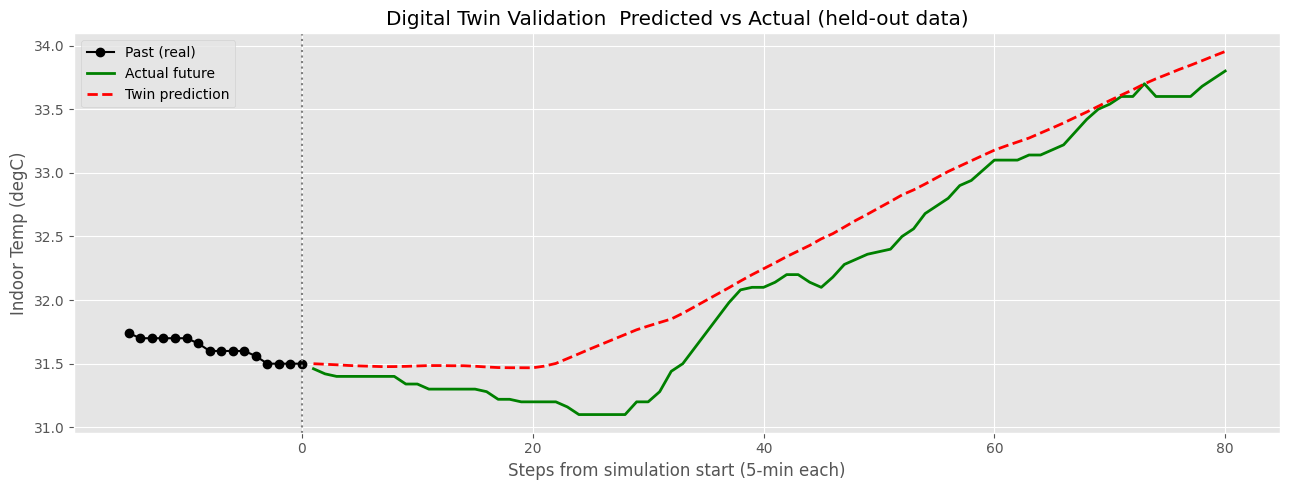

In [7]:
df_test = df_twin.iloc[split:].reset_index(drop=True)
HORIZON = 80
past_context = 15

start_idx = past_context
for i in range(past_context, len(df_test) - HORIZON - 1):
    if df_test["AC_State"].iloc[i + 1] != df_test["AC_State"].iloc[i]:
        start_idx = i
        break

current_temp = df_test["IndoorTemp"].iloc[start_idx]
current_lag1 = df_test["IndoorTemp_Lag1"].iloc[start_idx]
current_ac_lag1 = df_test["AC_State_Lag1"].iloc[start_idx]
constant_h = df_test["IndoorHumidity"].iloc[start_idx]
temp_history = list(df_test["IndoorTemp"].iloc[start_idx - 11: start_idx + 1].values)

predictions = []
actuals = df_test["IndoorTemp"].iloc[start_idx + 1: start_idx + 1 + HORIZON].values

for step in range(HORIZON):
    idx = start_idx + step + 1
    ac = df_test["AC_State"].iloc[idx]  # real historical schedule, for a like-for-like test
    temp_diff = df_test["OutdoorTemp"].iloc[idx] - current_temp
    temp_change_rate = current_temp - current_lag1
    indoor_roll_1hr = np.mean(temp_history[-12:])
    indoor_lag12 = temp_history[-12]

    X_step = np.array([[
        current_temp, constant_h, df_test["OutdoorTemp"].iloc[idx], df_test["OutdoorHumidity"].iloc[idx],
        df_test["Rain"].iloc[idx], df_test["CloudCover"].iloc[idx], df_test["WindSpeed"].iloc[idx],
        temp_diff, ac, df_test["Hour_sin"].iloc[idx], df_test["Hour_cos"].iloc[idx],
        current_lag1, temp_change_rate, current_ac_lag1,
        indoor_roll_1hr, df_test["OutdoorTemp_RollingMean_4hr"].iloc[idx], indoor_lag12
    ]])
    delta = twin_validate.predict(X_step)[0]
    next_temp = current_temp + delta
    predictions.append(next_temp)

    current_lag1, current_ac_lag1, current_temp = current_temp, ac, next_temp
    temp_history.append(next_temp)

rmse = np.sqrt(mean_squared_error(actuals, predictions))
print(f"Free-run RMSE over {HORIZON} steps (~{HORIZON*5/60:.1f} hours): {rmse:.2f} degC")

plt.figure(figsize=(13, 5))
plt.plot(range(-past_context, 1), df_test["IndoorTemp"].iloc[start_idx-past_context:start_idx+1].values, "o-", color="black", label="Past (real)")
plt.plot(range(1, HORIZON+1), actuals, color="green", linewidth=2, label="Actual future")
plt.plot(range(1, HORIZON+1), predictions, color="red", linestyle="--", linewidth=2, label="Twin prediction")
plt.axvline(0, color="grey", linestyle=":")
plt.title("Digital Twin Validation  Predicted vs Actual (held-out data)")
plt.xlabel("Steps from simulation start (5-min each)")
plt.ylabel("Indoor Temp (degC)")
plt.legend()
plt.tight_layout()
plt.show()


In [8]:
# Refit on ALL data for the control-design step below.
# (Standard practice: validate on held-out data first, then use all available
# observations for the final model used in policy search / deployment.)
twin_model = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.03,
                           subsample=0.8, colsample_bytree=0.8, objective="reg:squarederror")
twin_model.fit(df_twin[FEATURES_TWIN].values, df_twin["Target_Delta_Next_Step"].values)
print("Digital twin refit on the full dataset for control design.")


Digital twin refit on the full dataset for control design.


## Part 5 Real Occupancy Calendar

This is the fairness fix your teammate raised: **both** the baseline and the optimized
policy are only ever allowed to run the AC during real occupied windows. Non-class days
(`NO_CLASS_DAYS`) get zero AC in both scenarios no more baseline inflated by hours
that were never actually going to be spent.


In [9]:
def get_occupied_day_windows(df, no_class_days, hour_start, hour_end):
    windows = []
    steps_per_window = (hour_end - hour_start) * (60 // SAMPLE_MINUTES)
    for d in sorted(df["Datetime"].dt.date.unique()):
        day_name = df.loc[df["Datetime"].dt.date == d, "DayName"].iloc[0]
        if day_name in no_class_days:
            continue
        match = df.index[(df["Datetime"].dt.date == d) & (df["Hour"] == hour_start)]
        if len(match) == 0:
            continue
        start_idx = match[0]
        if start_idx < 12 or start_idx + steps_per_window >= len(df):
            continue  # not enough history/future to simulate safely
        windows.append((d, start_idx, steps_per_window))
    return windows

day_windows = get_occupied_day_windows(df_twin, NO_CLASS_DAYS, OCCUPIED_HOUR_START, OCCUPIED_HOUR_END)
print(f"Occupied days found in this dataset: {[str(d) for d, _, _ in day_windows]}")
print("NOTE: this is one week of data, so this is a small-sample proof of concept")
print("collecting more weeks would make the savings estimate below more robust.")


Occupied days found in this dataset: ['2026-06-24', '2026-06-26', '2026-06-27', '2026-06-28']
NOTE: this is one week of data, so this is a small-sample proof of concept
collecting more weeks would make the savings estimate below more robust.


## Part 6 Search for an Optimized Control Policy (Using the Twin as the Environment)

This is the core of your teammate's suggestion. Instead of a classifier, we define a
small, fully interpretable **hysteresis thermostat**: turn ON once the room reaches
`T_on`, turn OFF once it drops to `T_off`, otherwise hold the previous state. We
simulate every `(T_on, T_off)` combination on every occupied day through the digital
twin, and keep the combination that uses the **least total runtime** while keeping the
simulated temperature at or below `COMFORT_MAX_C` (within a small tolerance).

The result is a two-number control rule you could genuinely deploy on a simple
thermostat not a black-box classifier.


In [10]:
def simulate_day(model, df, feature_cols, start_idx, horizon, policy_fn):
    current_temp = df["IndoorTemp"].iloc[start_idx]
    current_lag1 = df["IndoorTemp_Lag1"].iloc[start_idx]
    current_ac_lag1 = df["AC_State_Lag1"].iloc[start_idx]
    constant_h = df["IndoorHumidity"].iloc[start_idx]
    temp_history = list(df["IndoorTemp"].iloc[start_idx - 11: start_idx + 1].values)
    prev_ac = int(df["AC_State"].iloc[start_idx])

    temps, ac_used = [], []
    for step in range(horizon):
        idx = start_idx + step + 1
        if idx >= len(df):
            break
        ac = policy_fn(current_temp, prev_ac)
        temp_diff = df["OutdoorTemp"].iloc[idx] - current_temp
        temp_change_rate = current_temp - current_lag1
        indoor_roll_1hr = np.mean(temp_history[-12:])
        indoor_lag12 = temp_history[-12]

        X_step = np.array([[
            current_temp, constant_h, df["OutdoorTemp"].iloc[idx], df["OutdoorHumidity"].iloc[idx],
            df["Rain"].iloc[idx], df["CloudCover"].iloc[idx], df["WindSpeed"].iloc[idx],
            temp_diff, ac, df["Hour_sin"].iloc[idx], df["Hour_cos"].iloc[idx],
            current_lag1, temp_change_rate, current_ac_lag1,
            indoor_roll_1hr, df["OutdoorTemp_RollingMean_4hr"].iloc[idx], indoor_lag12
        ]])
        delta = model.predict(X_step)[0]
        next_temp = current_temp + delta

        temps.append(next_temp)
        ac_used.append(ac)
        current_lag1, current_ac_lag1, current_temp, prev_ac = current_temp, ac, next_temp, ac
        temp_history.append(next_temp)

    return temps, ac_used


def make_hysteresis(t_on, t_off):
    def policy(temp, prev_ac):
        if temp >= t_on:
            return 1
        if temp <= t_off:
            return 0
        return prev_ac
    return policy


baseline_policy = lambda temp, prev_ac: 1  # naive "leave it on the whole occupied window"

In [11]:
# GRID SEARCH over hysteresis thresholds
T_ON_CANDIDATES = np.arange(24.5, 28.0, 0.5)
T_OFF_CANDIDATES = np.arange(21.0, 25.0, 0.5)

search_rows = []
for t_on, t_off in product(T_ON_CANDIDATES, T_OFF_CANDIDATES):
    if t_off >= t_on:
        continue
    policy = make_hysteresis(t_on, t_off)
    total_ac_steps, max_temp_seen = 0, -np.inf
    for (_, start_idx, horizon) in day_windows:
        temps, ac_used = simulate_day(twin_model, df_twin, FEATURES_TWIN, start_idx, horizon, policy)
        total_ac_steps += sum(ac_used)
        if temps:
            max_temp_seen = max(max_temp_seen, max(temps))
    search_rows.append({"T_on": t_on, "T_off": t_off, "Total_AC_Steps": total_ac_steps, "Max_Temp_Reached": max_temp_seen})

search_df = pd.DataFrame(search_rows)
feasible = search_df[search_df["Max_Temp_Reached"] <= COMFORT_MAX_C + VIOLATION_TOLERANCE_C]

if len(feasible):
    best_row = feasible.loc[feasible["Total_AC_Steps"].idxmin()]
else:
    print("No combination stayed within the comfort ceiling falling back to the lowest-overshoot option.")
    best_row = search_df.loc[search_df["Max_Temp_Reached"].idxmin()]

best_t_on, best_t_off = best_row["T_on"], best_row["T_off"]
print(f"Best policy found: turn ON at {best_t_on} degC, turn OFF at {best_t_off} degC")
print(f"Predicted max temp reached: {best_row['Max_Temp_Reached']:.2f} degC  (ceiling: {COMFORT_MAX_C} degC)")
display(search_df.sort_values("Total_AC_Steps").head(10))

No combination stayed within the comfort ceiling falling back to the lowest-overshoot option.
Best policy found: turn ON at 24.5 degC, turn OFF at 21.0 degC
Predicted max temp reached: 31.27 degC  (ceiling: 26.0 degC)


,T_on,T_off,Total_AC_Steps,Max_Temp_Reached
54,27.5,24.5,342,31.273769
51,27.5,23.0,344,31.273769
53,27.5,24.0,362,31.273769
38,26.5,24.5,366,31.273769
48,27.5,21.5,372,31.273769
52,27.5,23.5,376,31.273769
47,27.5,21.0,381,31.273769
46,27.0,24.5,389,31.273769
50,27.5,22.5,393,31.273769
49,27.5,22.0,395,31.273769


## Part 7 Baseline vs Optimized Policy (Simulated, Same Physics Engine)

Both schedules are simulated through the identical digital twin, over the identical
occupied windows the only thing that differs is the control rule. This directly
answers your teammate's comfort concern: we can see, in simulation, whether the
optimized policy keeps the room just as usable while running less.


In [12]:
best_policy = make_hysteresis(best_t_on, best_t_off)

sim_rows = []
for (d, start_idx, horizon) in day_windows:
    temps_base, ac_base = simulate_day(twin_model, df_twin, FEATURES_TWIN, start_idx, horizon, baseline_policy)
    temps_opt, ac_opt = simulate_day(twin_model, df_twin, FEATURES_TWIN, start_idx, horizon, best_policy)
    for step in range(min(len(temps_base), len(temps_opt))):
        idx = start_idx + step + 1
        sim_rows.append({
            "Date": d,
            "Datetime": df_twin["Datetime"].iloc[idx],
            "Hour": df_twin["Hour"].iloc[idx],
            "Baseline_Temp": temps_base[step], "Baseline_AC": ac_base[step],
            "Optimized_Temp": temps_opt[step], "Optimized_AC": ac_opt[step],
        })

df_sim = pd.DataFrame(sim_rows)

baseline_runtime_hr = df_sim["Baseline_AC"].sum() * SAMPLE_MINUTES / 60
ai_runtime_hr = df_sim["Optimized_AC"].sum() * SAMPLE_MINUTES / 60
data_span_days = len(day_windows) * (OCCUPIED_HOUR_END - OCCUPIED_HOUR_START) / 24

print(f"Baseline runtime   : {baseline_runtime_hr:.2f} hours  (always on during occupied hours)")
print(f"Optimized runtime  : {ai_runtime_hr:.2f} hours")
print(f"Baseline max temp  : {df_sim['Baseline_Temp'].max():.2f} degC")
print(f"Optimized max temp : {df_sim['Optimized_Temp'].max():.2f} degC   (ceiling: {COMFORT_MAX_C} degC)")


Baseline runtime   : 48.00 hours  (always on during occupied hours)
Optimized runtime  : 40.83 hours
Baseline max temp  : 31.27 degC
Optimized max temp : 31.27 degC   (ceiling: 26.0 degC)


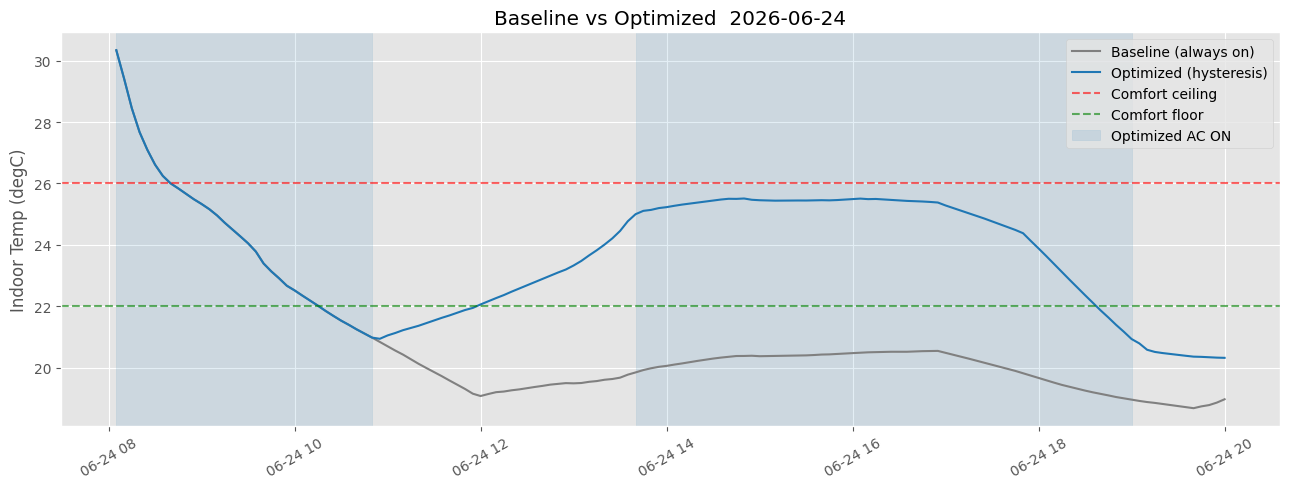

In [13]:
# COMFORT COMPARISON PLOT  one example occupied day
example_date = day_windows[0][0]
sub = df_sim[df_sim["Date"] == example_date]

plt.figure(figsize=(13, 5))
plt.plot(sub["Datetime"], sub["Baseline_Temp"], color="gray", label="Baseline (always on)")
plt.plot(sub["Datetime"], sub["Optimized_Temp"], color="tab:blue", label="Optimized (hysteresis)")
plt.axhline(COMFORT_MAX_C, color="red", linestyle="--", alpha=0.6, label="Comfort ceiling")
plt.axhline(COMFORT_MIN_C, color="green", linestyle="--", alpha=0.6, label="Comfort floor")
plt.fill_between(sub["Datetime"], 0, 1, where=(sub["Optimized_AC"] == 1),
                  transform=plt.gca().get_xaxis_transform(), color="tab:blue", alpha=0.12, label="Optimized AC ON")
plt.title(f"Baseline vs Optimized  {example_date}")
plt.ylabel("Indoor Temp (degC)")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()


## Part 8 Energy, Cost & Environmental Impact

Same calculations as before, now fed by the simulated, comfort-validated, fair
comparison from Part 7 instead of classifier predictions on a guessed label.


In [14]:
# --- 8.1 Energy consumption ---
baseline_energy_kwh = baseline_runtime_hr * AC_POWER_KW
ai_energy_kwh = ai_runtime_hr * AC_POWER_KW
energy_saved_kwh = baseline_energy_kwh - ai_energy_kwh
energy_saving_pct = (energy_saved_kwh / baseline_energy_kwh) * 100 if baseline_energy_kwh else 0

# --- 8.2 Electricity cost ---
baseline_cost = baseline_energy_kwh * TARIFF_RM_PER_KWH
ai_cost = ai_energy_kwh * TARIFF_RM_PER_KWH
cost_saved = baseline_cost - ai_cost

# --- 8.3 CO2 avoided ---
co2_avoided_kg = energy_saved_kwh * GRID_EMISSION_FACTOR

# --- 8.4 Relatable equivalents ---
trees_equivalent = co2_avoided_kg / TREE_ABSORPTION_KG_YR
km_not_driven_equivalent = co2_avoided_kg / CAR_EMISSION_KG_KM

# --- 8.5 Peak-hour demand reduction ---
peak_mask = (df_sim["Hour"] >= PEAK_HOUR_START) & (df_sim["Hour"] < PEAK_HOUR_END)
baseline_peak_hr = df_sim.loc[peak_mask, "Baseline_AC"].sum() * SAMPLE_MINUTES / 60
ai_peak_hr = df_sim.loc[peak_mask, "Optimized_AC"].sum() * SAMPLE_MINUTES / 60
peak_reduction_pct = (1 - ai_peak_hr / baseline_peak_hr) * 100 if baseline_peak_hr > 0 else 0

# --- 8.6 Annualized projection (extrapolated flagged clearly as such) ---
yearly_factor = 365 / data_span_days if data_span_days > 0 else 0
projected_yearly_cost_saved = cost_saved * yearly_factor
projected_yearly_co2_avoided_tonnes = (co2_avoided_kg * yearly_factor) / 1000

print("Impact metrics calculated from the simulated, comfort-validated comparison.")


Impact metrics calculated from the simulated, comfort-validated comparison.


In [15]:
summary = pd.DataFrame({
    "Metric": ["AC Runtime (hours)", "Energy Consumption (kWh)", "Electricity Cost (RM)", "CO2 Emissions (kg)"],
    "Baseline": [round(baseline_runtime_hr, 2), round(baseline_energy_kwh, 2), round(baseline_cost, 2),
                 round(baseline_energy_kwh * GRID_EMISSION_FACTOR, 2)],
    "Optimized": [round(ai_runtime_hr, 2), round(ai_energy_kwh, 2), round(ai_cost, 2),
                  round(ai_energy_kwh * GRID_EMISSION_FACTOR, 2)],
})
summary["Savings"] = [round(baseline_runtime_hr - ai_runtime_hr, 2), round(energy_saved_kwh, 2),
                       round(cost_saved, 2), round(co2_avoided_kg, 2)]
summary["Savings %"] = [
    round((1 - ai_runtime_hr / baseline_runtime_hr) * 100, 1) if baseline_runtime_hr else 0,
    round(energy_saving_pct, 1),
    round((cost_saved / baseline_cost) * 100, 1) if baseline_cost else 0,
    round((co2_avoided_kg / (baseline_energy_kwh * GRID_EMISSION_FACTOR)) * 100, 1) if baseline_energy_kwh else 0,
]
display(summary)

print(f"\nComfort check: optimized max temp {df_sim['Optimized_Temp'].max():.2f} degC vs ceiling {COMFORT_MAX_C} degC")
print(f"Relatable equivalents: {trees_equivalent:.1f} tree-years of CO2 absorption, {km_not_driven_equivalent:.0f} km not driven")
print(f"Peak-hour ({PEAK_HOUR_START}:00-{PEAK_HOUR_END}:00) runtime reduction: {peak_reduction_pct:.1f}%")
print(f"\nProjected over a year (extrapolated from {len(day_windows)} observed occupied days):")
print(f"  - Cost saved  : RM {projected_yearly_cost_saved:.2f}")
print(f"  - CO2 avoided : {projected_yearly_co2_avoided_tonnes:.3f} tonnes")


,Metric,Baseline,Optimized,Savings,Savings %
0,AC Runtime (hours),48.00,40.83,7.17,14.9
1,Energy Consumption (kWh),134.40,114.33,20.07,14.9
2,Electricity Cost (RM),61.02,51.91,9.11,14.9
3,CO2 Emissions (kg),104.03,88.49,15.53,14.9



Comfort check: optimized max temp 31.27 degC vs ceiling 26.0 degC
Relatable equivalents: 0.7 tree-years of CO2 absorption, 129 km not driven
Peak-hour (14:00-17:00) runtime reduction: 0.7%

Projected over a year (extrapolated from 4 observed occupied days):
  - Cost saved  : RM 1662.62
  - CO2 avoided : 2.835 tonnes


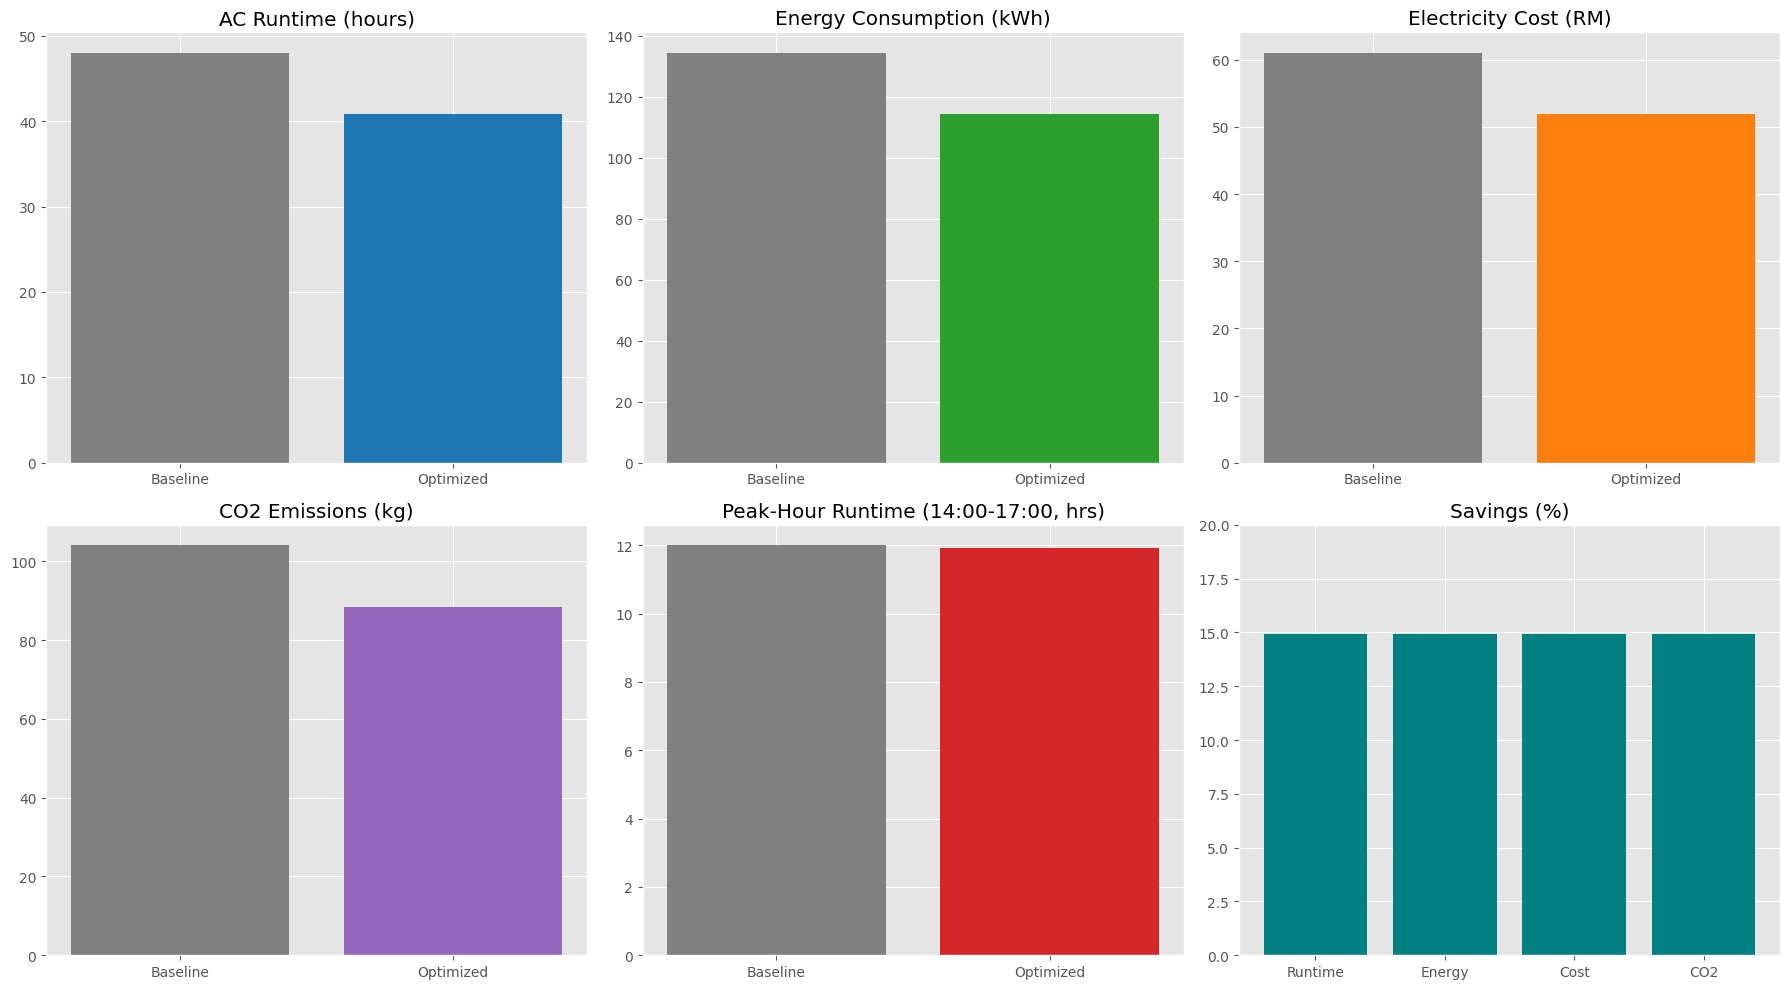

In [16]:
fig, ax = plt.subplots(2, 3, figsize=(18, 10))

ax[0, 0].bar(["Baseline", "Optimized"], [baseline_runtime_hr, ai_runtime_hr], color=["gray", "tab:blue"])
ax[0, 0].set_title("AC Runtime (hours)")

ax[0, 1].bar(["Baseline", "Optimized"], [baseline_energy_kwh, ai_energy_kwh], color=["gray", "tab:green"])
ax[0, 1].set_title("Energy Consumption (kWh)")

ax[0, 2].bar(["Baseline", "Optimized"], [baseline_cost, ai_cost], color=["gray", "tab:orange"])
ax[0, 2].set_title("Electricity Cost (RM)")

ax[1, 0].bar(["Baseline", "Optimized"],
             [baseline_energy_kwh * GRID_EMISSION_FACTOR, ai_energy_kwh * GRID_EMISSION_FACTOR],
             color=["gray", "tab:purple"])
ax[1, 0].set_title("CO2 Emissions (kg)")

ax[1, 1].bar(["Baseline", "Optimized"], [baseline_peak_hr, ai_peak_hr], color=["gray", "tab:red"])
ax[1, 1].set_title(f"Peak-Hour Runtime ({PEAK_HOUR_START}:00-{PEAK_HOUR_END}:00, hrs)")

ax[1, 2].bar(["Runtime", "Energy", "Cost", "CO2"],
             [(1 - ai_runtime_hr / baseline_runtime_hr) * 100 if baseline_runtime_hr else 0,
              energy_saving_pct,
              (cost_saved / baseline_cost) * 100 if baseline_cost else 0,
              (co2_avoided_kg / (baseline_energy_kwh * GRID_EMISSION_FACTOR)) * 100 if baseline_energy_kwh else 0],
             color="teal")
ax[1, 2].set_title("Savings (%)")
ax[1, 2].set_ylim(0, 20)

plt.tight_layout()
plt.show()


## Part 9 Save Final Artifacts

The deployable "AI" here is genuinely simple: a two-number thermostat rule
(`T_on`, `T_off`), physics-validated via the digital twin. No black-box classifier
needs to run on the device.


In [17]:
joblib.dump(twin_model, "RoomDigitalTwin.pkl")
joblib.dump(FEATURES_TWIN, "twin_feature_columns.pkl")
policy_params = {"T_on": float(best_t_on), "T_off": float(best_t_off),
                  "no_class_days": NO_CLASS_DAYS,
                  "occupied_hours": [OCCUPIED_HOUR_START, OCCUPIED_HOUR_END]}
joblib.dump(policy_params, "OptimizedThermostatPolicy.pkl")
df_sim.to_csv("Baseline_vs_Optimized_Simulation.csv", index=False)